# Multiple Linear Regression
---
<h3>Anshu Chaudhary</h3> <hr><h4>13 Feb 2023


<div>
<img src="https://digitaluncut.com/wp-content/uploads/2022/08/shutterstock_1023171385-2-1280x738.jpg" width="900" align="centre"/>

</div>

>### Dataset
> This dataset contains information about Profits of 50 different Startups in 3 different states.<br> A Multiple Linear Regression Machine learning model is created here to predict the profits of Startups 

<hr>

In [1]:
# Necessary imports:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [2]:
#additional imports
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.decomposition import PCA

In [3]:
data = pd.read_csv('50_Startups.csv')
data.shape

(50, 5)

In [4]:
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


We can see that there are five columns in this dataset.

R&D Spend	
Administration	
Marketing Spend	State	
Profit

From this dataset, we will analyze how the columns for R&D spending, administration, marketing spending, and state will affect calculating profit.

Profit is the dependent variable in this case.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [6]:
data.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [7]:
# Statistical summary
data.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


## Visualisation

### Dataset

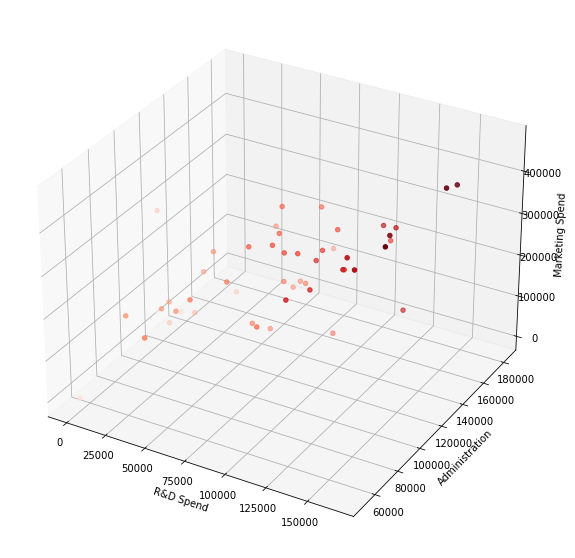

In [8]:
plt.rcParams['figure.figsize'] = (10.0, 10.0)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

rd_spend = data["R&D Spend"]
admin = data["Administration"]
marketing_spend = data["Marketing Spend"]
profit = data["Profit"]
# Ploting rd_spend, admin, marketing_spend as scatter plot
# Higher the profit darker the color of the point
ax.scatter(rd_spend, admin, marketing_spend, c=profit, cmap='Reds')
ax.set_xlabel('R&D Spend')
ax.set_ylabel('Administration')
ax.set_zlabel('Marketing Spend')

plt.show()

### State Distribution

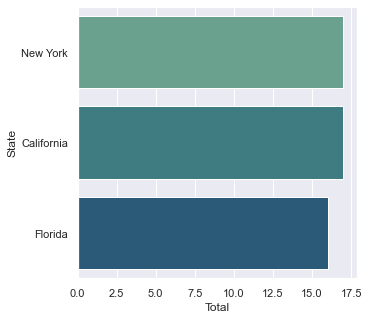

In [9]:
plt.rcParams['figure.figsize'] = (5.0, 5)
sns.set_theme(style="darkgrid")
sns.countplot(y="State", data=data, palette="crest")
plt.ylabel('State')
plt.xlabel('Total')
plt.show()

### Bloxplots

<AxesSubplot:xlabel='R&D Spend'>

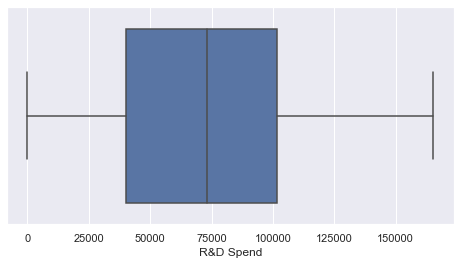

In [10]:
plt.rcParams['figure.figsize'] = (8.0, 4.0)
sns.boxplot(x = data["R&D Spend"])

<AxesSubplot:xlabel='Administration'>

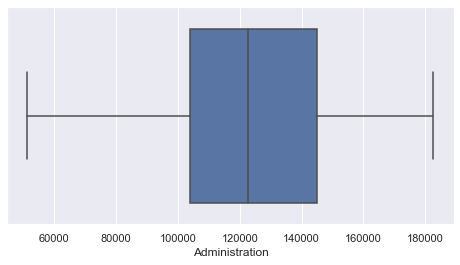

In [11]:
sns.boxplot(x = data["Administration"])

<AxesSubplot:xlabel='Marketing Spend'>

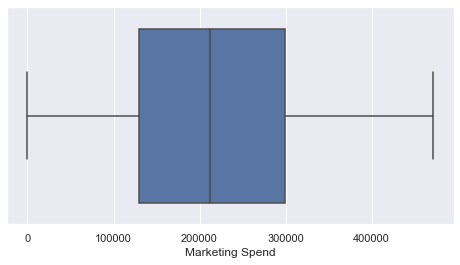

In [12]:
sns.boxplot(x = data["Marketing Spend"])

<AxesSubplot:xlabel='Profit'>

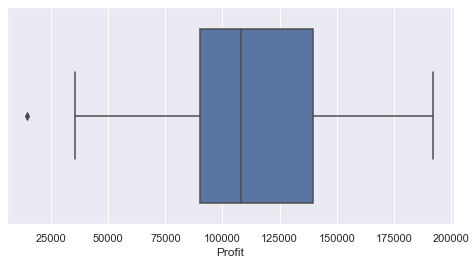

In [13]:
sns.boxplot(x = data["Profit"])

You can see that target varaible "Profit" that contains outlier.

In [14]:
'''Remove outliers are target variable'''
Q3, Q1 = np.percentile(data["Profit"], [75 ,25])
IQR = Q3 - Q1
print(IQR)
data = data[~(data.Profit< (Q1 - 1.5*IQR))]

49627.07499999998


Box plot after removing outlier in 'Profit'

<AxesSubplot:xlabel='Profit'>

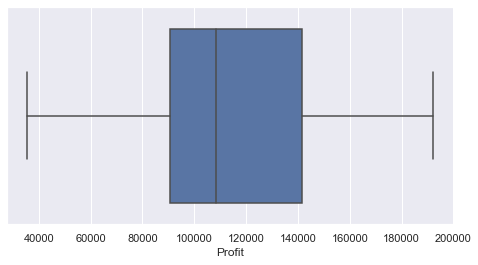

In [15]:
sns.boxplot(x = data["Profit"])

### Visualise the entire dataset¶

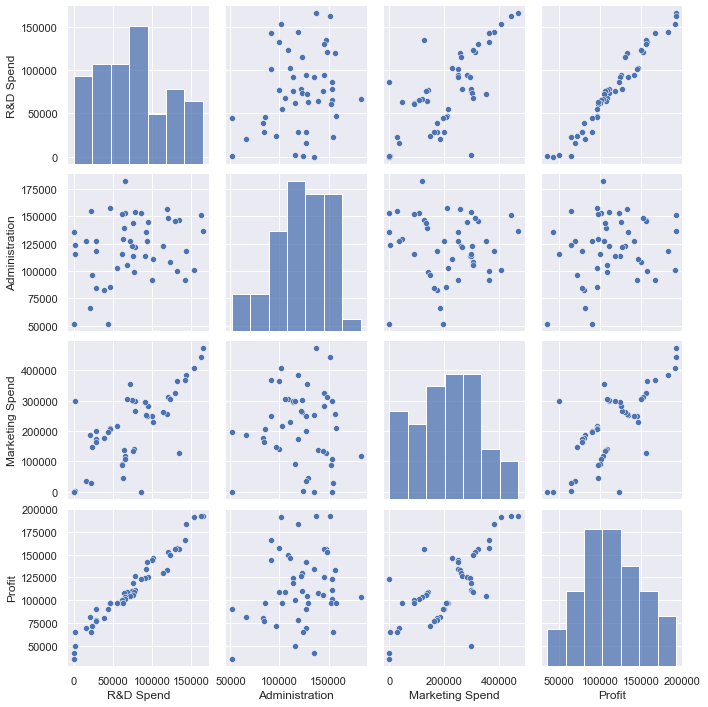

In [16]:
sns.pairplot(data)

In [17]:
data.head(15)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


Since 'State' contains categorical data we encode the data by using Dummy Variables, We take 3 Dummy Variable 
But since Dummy Variables for State_California, State_Florida and State_New York are highly correlated or multicollinear because if the data does not belong to State_California or State_Florida then it is sure, the data belongs to State_NewYork this will lead to a Dummy variable trap.

To overcome the Dummy variable Trap, we drop one of the columns created when the categorical variables were converted to dummy variables. This can be done because the dummy variables include redundant information.

That can be done by X=pd.get_dummies(X, drop_first=True), which will drop one dummy variable.

In [18]:
data = pd.get_dummies(data, drop_first=True)
data.head(15)

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


### Heatmap

In [19]:
plt.figure(figsize=(8,6))
sns.set_context('paper',font_scale=1.4)

corr_matrix=data.corr()
corr_matrix

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
R&D Spend,1.000000,0.243438,0.711654,0.978437,0.085734,0.015816
Administration,0.243438,1.000000,-0.037280,0.205841,0.008334,0.002858
Marketing Spend,0.711654,-0.037280,1.000000,0.739307,0.191104,-0.055087
Profit,0.978437,0.205841,0.739307,1.000000,0.088008,-0.004679
State_Florida,0.085734,0.008334,0.191104,0.088008,1.000000,-0.507519
State_New York,0.015816,0.002858,-0.055087,-0.004679,-0.507519,1.000000


<Figure size 576x432 with 0 Axes>

<AxesSubplot:>

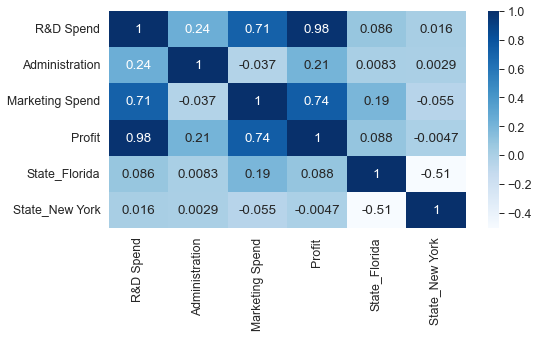

In [20]:
sns.heatmap(corr_matrix,annot=True,cmap='Blues')

There is high correlation between(dep. var and indep. var):  
Profit and R&D spend<br>Profit and Marketing Spend

There is high correlation between(indep. var and indep. var):  
Marketing Spend and R&D spend

Additionally profits for the state 'New York' is the worst

# Model Construction

Identifying the dependent and independent variables and 
 Splitting the Data into Training and Testing Sets

In [21]:
X = data.drop(data[['Profit']], axis=1).to_numpy()
y = data[['Profit']].to_numpy().reshape(-1, 1)

In [22]:
x1 = np.hstack((np.ones((X.shape[0], 1)), X))
# Split the data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x1, y, train_size=0.3, random_state=0)

## Computing Multiple Linear Regression

### RMSProp
RMSProp (Root Mean Square Propagation) is an optimization algorithm that is often used in deep learning and can be used to optimize linear regression models as well.

Here RMSProp is used instead of gradient descent as gradient descent seemed inappropriate for proper optimization for the dataset. Unlike gradient descent, which uses the same learning rate for all parameters, RMSProp dynamically adjusts the learning rate for each parameter based on the historical gradient information. This helps RMSProp to handle cases where some parameters may converge more slowly than others.

<div>
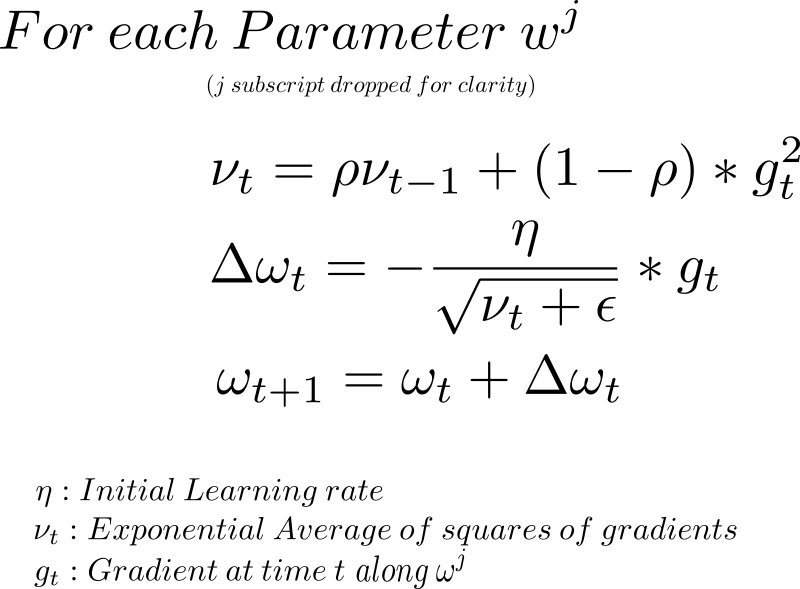
</div>
<br>
<div style="text-align: center;">
    
### g2_t = decay_rate * g2_{t-1} + (1 - decay_rate) * g_t^2

### theta_t = theta_{t-1} - learning_rate * g_t / (sqrt(g2_t) + epsilon)
</div>
<br>

Where decay_rate is a hyperparameter that controls the decay rate of the moving average, learning_rate is a hyperparameter that controls the step size of the optimization, and epsilon is a small positive number added to the denominator to prevent division by zero.

In [23]:
def RMSProp(X,y,learning_rate = 0.01,decay_rate = 0.9,epsilon = 1e-10):
    '''Takes in independent variable and dependent variable 
    with optional parameters learning_rate, decay_rate, epsilon and performs RMSProp Optimization.
    
    learning_rate: Initial value for the learning rate,Default 0.01.
    epsilon: A small constant for numerical stability, Defaults to 1e-10.
    decay_rate: decays the learning rate over time,
                so we can move even closer to the local minimum in the end of training
                
     '''
    # Initialize the parameter
    theta = np.zeros((X.shape[1], 1))
    # Initialize the moving average of squared gradient
    g2 = np.zeros((X.shape[1], 1))

    # Perform the optimization
    for i in range(15000000):
        # Compute the gradient
        y_pred = X.dot(theta)
        grad = X.T.dot(y_pred - y) / X.shape[0]

        # Update the moving average of squared gradient
        g2 = decay_rate * g2 + (1 - decay_rate) * grad**2

        # Update the parameters
        theta -= learning_rate * grad / (np.sqrt(g2) + epsilon)
        
    return y_pred,theta

In [24]:
y_pred,w = RMSProp(x_train,y_train)

Predicting for test data set

In [25]:
y_pred_test = x_test.dot(w)

In [26]:
df=pd.DataFrame(data={'Predicted value':y_pred_test.flatten(),'Actual Value':y_test.flatten()})
df.head(10)

,Predicted value,Actual Value
0,111233.393763,101004.64
1,177265.902143,166187.94
2,122970.545291,105733.54
3,109787.019860,99937.59
4,98316.563557,97427.84
5,80956.644427,89949.14
6,89653.610448,96712.80
7,72452.184397,78239.91
8,170403.880714,155752.60
9,143862.755901,146121.95


## Evaluation Metrics

Metrics for train

In [27]:
print("MAE", metrics.mean_absolute_error(y_train, y_pred))
print("MSE", metrics.mean_squared_error(y_train, y_pred))
print("RMSE",np.sqrt(metrics.mean_squared_error(y_train,y_pred)))
print("r2_score", metrics.r2_score(y_train, y_pred))

MAE 5310.000359057027
MSE 39452157.256489895
RMSE 6281.095227465501
r2_score 0.9798231601096112


Metrics for test

In [28]:
print("MAE", metrics.mean_absolute_error(y_test, y_pred_test))
print("MSE", metrics.mean_squared_error(y_test, y_pred_test))
print("RMSE",np.sqrt(metrics.mean_squared_error(y_test,y_pred_test)))
print("r2_score", metrics.r2_score(y_test, y_pred_test))

MAE 10113.114605994104
MSE 135565039.01798412
RMSE 11643.240056701748
r2_score 0.8878822159154869


## Rescaling And Performing PCA

In [29]:
def standardize(x):
    ''' Standardize the pixel values by subtracting the mean and dividing by the standard deviation '''
    mean = np.mean(x)
    std = np.std(x)
    return (x - mean) / std

In [30]:
def reduce_dim(x):
    ''' Standardize the pixel values by subtracting the mean and dividing by the standard deviation 
    Returns dataset with reduced features '''
    X_scaled =  standardize(x)
    # Create a PCA object
    pca = PCA(n_components=4)

    # Fit the PCA model to the input data
    pca.fit(X_scaled)
    
    # Transform the input data to the first two principal components
    X_pca = pca.transform(X_scaled)
    explained_variance = pca.explained_variance_ratio_
    print(explained_variance)
    X_original = X_pca * np.std(x) + np.mean(x)
    return X_original

## Computing Multiple Linear Regression on new dataset with reduced features

In [31]:
x0 = reduce_dim(X)
x2 = np.hstack((np.ones((x0.shape[0], 1)), x0))
# Split the data into training and test sets
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y, train_size=0.3, random_state=0)

[9.00940127e-01 6.89674237e-02 3.00924495e-02 1.90465866e-11]


In [32]:
y_pred2,w = RMSProp(x2_train,y2_train)

Predicting for test data set

In [33]:
y_pred2_test = x2_test.dot(w)

In [34]:
df=pd.DataFrame(data={'Predicted value':y_pred2_test.flatten(),'Actual Value':y2_test.flatten()})
df.head(10)

,Predicted value,Actual Value
0,106802.114632,101004.64
1,172099.517742,166187.94
2,114884.508658,105733.54
3,102712.106935,99937.59
4,102649.233967,97427.84
5,91011.067684,89949.14
6,95586.906288,96712.80
7,80028.577666,78239.91
8,162926.223202,155752.60
9,137472.497708,146121.95


In [35]:
df=pd.DataFrame(data={'Predicted value with PCA':y_pred2.flatten(),'Without PCA':y_pred.flatten(),'Actual':y_train.flatten()})
df

,Predicted value with PCA,Without PCA,Actual
0,64255.214338,66625.543523,69758.98
1,113118.034288,114488.250748,108552.04
2,156894.269447,153567.464853,156122.51
3,109679.004651,112832.459545,108733.99
4,77997.396018,82455.257800,90708.19
5,118185.675573,119769.110545,111313.02
6,117469.874767,123418.302504,122776.86
7,152054.646890,144275.958736,149759.96
8,84564.397363,75142.102252,81005.76
9,52457.984927,54756.097525,64926.08


Metrics for train

In [36]:
print("MAE", metrics.mean_absolute_error(y2_train, y_pred2))
print("MSE", metrics.mean_squared_error(y2_train, y_pred2))
print("RMSE",np.sqrt(metrics.mean_squared_error(y2_train,y_pred2)))
print("r2_score", metrics.r2_score(y2_train, y_pred2))

MAE 6120.785083841167
MSE 53784979.51149334
RMSE 7333.824344194054
r2_score 0.9724929890891398


Metrics for test

In [37]:
print("MAE", metrics.mean_absolute_error(y2_test, y_pred2_test))
print("MSE", metrics.mean_squared_error(y2_test, y_pred2_test))
print("RMSE",np.sqrt(metrics.mean_squared_error(y2_test,y_pred2_test)))
print("r2_score", metrics.r2_score(y2_test, y_pred2_test))

MAE 6692.7337987805
MSE 69275090.38855314
RMSE 8323.1658873624
r2_score 0.9427066913204033


| Metrics                 	| Original Train     	| PCA Train          	| Original Test      	| PCA Test           	|
|:-------------------------	|:--------------------	|:--------------------	|:--------------------	|:--------------------	|
| Mean Absolute Error     	| 5310.000359057027  	| 6120.785083841167  	| 10113.114605994104 	| 6692.7337987805    	|
| Mean Squared Error      	| 39452157.256489895 	| 53784979.51149334  	| 135565039.01798412 	| 69275090.38855314  	|
| Root Mean Squared Error 	| 6281.095227465501  	| 7333.824344194054  	| 11643.240056701748 	| 8323.1658873624    	|
| r2_score                	| 0.9798231601096112 	| 0.9724929890891398 	| 0.8878822159154869 	| 0.9427066913204033 	|

<Figure size 864x576 with 0 Axes>

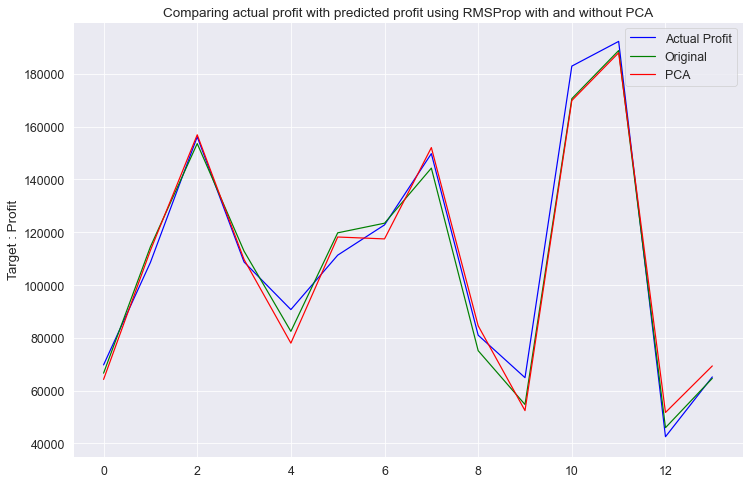

In [38]:
plt.figure(num=None, figsize=(12, 8))
plt.figure(num=None, figsize=(12, 8))
plt.plot(np.arange(14),y_train, color = "blue", label = 'Actual Profit') 
plt.plot(np.arange(14),y_pred, color = "green", label = 'Original') 
plt.plot(np.arange(14),y_pred2, color = "red", label = 'PCA') 
plt.ylabel("Target : Profit")
plt.title("Comparing actual profit with predicted profit using RMSProp with and without PCA")
plt.legend()
plt.show()

## Conclusion
In conclusion, the results obtained from performing multilinear regression with and without PCA before training have provided insights into the impact of dimensionality reduction on the model's performance. The results show that applying PCA before training the multilinear regression model can lead to improved performance in terms of model accuracy and computational efficiency. However, it is important to note that the benefits of using PCA in this manner may vary depending on the specifics of the dataset and the target application.